## Project Title: Best prediction model for Rusty used car sales to attract new prospective customers

## Introduction
##### The objective of this project is to find a best model which can provide assistance in finding value of the used car sales so that Rusty Bargain used car sales services can design an app to find the market values of used car prices. So prospective car buyer can decide if particular car is in their budget. It will help with quicker sales conversion, proper price prediction and more customer satisfaction for customer and more job satisfaction for employees. It will result into increase of EBITDA (Earning before interest, taxes, depreciation and amortization).

In [1]:
## Loading all the libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from scipy import stats as st
import time
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV

import lightgbm as lgb
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor


from catboost import CatBoostRegressor
from sklearn.metrics import roc_auc_score
from sklearn.metrics import mean_squared_error

In [2]:
## loading the dataframe
df = pd.read_csv('/datasets/car_data.csv')
df

,DateCrawled,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Mileage,RegistrationMonth,FuelType,Brand,NotRepaired,DateCreated,NumberOfPictures,PostalCode,LastSeen
0,24/03/2016 11:52,480,NaN,1993,manual,0,golf,150000,0,petrol,volkswagen,NaN,24/03/2016 00:00,0,70435,07/04/2016 03:16
1,24/03/2016 10:58,18300,coupe,2011,manual,190,NaN,125000,5,gasoline,audi,yes,24/03/2016 00:00,0,66954,07/04/2016 01:46
2,14/03/2016 12:52,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,NaN,14/03/2016 00:00,0,90480,05/04/2016 12:47
3,17/03/2016 16:54,1500,small,2001,manual,75,golf,150000,6,petrol,volkswagen,no,17/03/2016 00:00,0,91074,17/03/2016 17:40
4,31/03/2016 17:25,3600,small,2008,manual,69,fabia,90000,7,gasoline,skoda,no,31/03/2016 00:00,0,60437,06/04/2016 10:17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
354364,21/03/2016 09:50,0,NaN,2005,manual,0,colt,150000,7,petrol,mitsubishi,yes,21/03/2016 00:00,0,2694,21/03/2016 10:42
354365,14/03/2016 17:48,2200,NaN,2005,NaN,0,NaN,20000,1,NaN,sonstige_autos,NaN,14/03/2016 00:00,0,39576,06/04/2016 00:46
354366,05/03/2016 19:56,1199,convertible,2000,auto,101,fortwo,125000,3,petrol,smart,no,05/03/2016 00:00,0,26135,11/03/2016 18:17
354367,19/03/2016 18:57,9200,bus,1996,manual,102,transporter,150000,3,gasoline,volkswagen,no,19/03/2016 00:00,0,87439,07/04/2016 07:15


In [3]:
## Number of rows and column in the data frame
df.shape

(354369, 16)

## Data Preprocessing 

In [4]:
## Dropping the columns
df.drop(columns=['NumberOfPictures','PostalCode','LastSeen', 'DateCreated','RegistrationMonth'], inplace=True)
df

,DateCrawled,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Mileage,FuelType,Brand,NotRepaired
0,24/03/2016 11:52,480,NaN,1993,manual,0,golf,150000,petrol,volkswagen,NaN
1,24/03/2016 10:58,18300,coupe,2011,manual,190,NaN,125000,gasoline,audi,yes
2,14/03/2016 12:52,9800,suv,2004,auto,163,grand,125000,gasoline,jeep,NaN
3,17/03/2016 16:54,1500,small,2001,manual,75,golf,150000,petrol,volkswagen,no
4,31/03/2016 17:25,3600,small,2008,manual,69,fabia,90000,gasoline,skoda,no
...,...,...,...,...,...,...,...,...,...,...,...
354364,21/03/2016 09:50,0,NaN,2005,manual,0,colt,150000,petrol,mitsubishi,yes
354365,14/03/2016 17:48,2200,NaN,2005,NaN,0,NaN,20000,NaN,sonstige_autos,NaN
354366,05/03/2016 19:56,1199,convertible,2000,auto,101,fortwo,125000,petrol,smart,no
354367,19/03/2016 18:57,9200,bus,1996,manual,102,transporter,150000,gasoline,volkswagen,no


In [5]:
print(df.RegistrationYear.max())
print(df.DateCrawled.max())

9999
31/03/2016 23:58


In [6]:
df.dtypes

DateCrawled         object
Price                int64
VehicleType         object
RegistrationYear     int64
Gearbox             object
Power                int64
Model               object
Mileage              int64
FuelType            object
Brand               object
NotRepaired         object
dtype: object

In [7]:
df = df[(df['RegistrationYear']>= 1920) & (df['RegistrationYear'] <= 2016)]

In [8]:
print(df.RegistrationYear.min())


1920


In [9]:
df.drop(columns=['DateCrawled'], inplace=True)

/opt/conda/envs/python3/lib/python3.9/site-packages/pandas/core/frame.py:4308: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return super().drop(


##### Dropped columns like 'NumberOfPictures','PostalCode','LastSeen', 'DateCreated','RegistrationMonth'. These columns are not useful for out predictions as this will not have no impact on price prediction of a car. For Registration year I am dropping all the data which got resgistered after 

In [10]:
df.describe()

,Price,RegistrationYear,Power,Mileage
count,339670.000000,339670.000000,339670.000000,339670.000000
mean,4472.568290,2002.510225,111.029043,128106.853711
std,4546.110422,6.907464,186.890118,37864.073749
min,0.000000,1920.000000,0.000000,5000.000000
25%,1100.000000,1999.000000,69.000000,125000.000000
50%,2799.000000,2003.000000,105.000000,150000.000000
75%,6500.000000,2007.000000,143.000000,150000.000000
max,20000.000000,2016.000000,20000.000000,150000.000000


In [11]:
df.isna().sum()

Price                   0
VehicleType         22841
RegistrationYear        0
Gearbox             17833
Power                   0
Model               17561
Mileage                 0
FuelType            27173
Brand                   0
NotRepaired         64711
dtype: int64

 #### Found some missing values in vehicle type, gear box, model, fuel type, not repaired. The reason can be the employees forgot to input the data.

In [12]:
## changing the column headings into lower case
df.columns=df.columns.str.lower()

#### Changing the column name into lower case helps with remembering the column name better as we dont remember which is upper case or lower case

In [13]:
df.columns

Index(['price', 'vehicletype', 'registrationyear', 'gearbox', 'power', 'model',
       'mileage', 'fueltype', 'brand', 'notrepaired'],
      dtype='object')

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 339670 entries, 0 to 354368
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   price             339670 non-null  int64 
 1   vehicletype       316829 non-null  object
 2   registrationyear  339670 non-null  int64 
 3   gearbox           321837 non-null  object
 4   power             339670 non-null  int64 
 5   model             322109 non-null  object
 6   mileage           339670 non-null  int64 
 7   fueltype          312497 non-null  object
 8   brand             339670 non-null  object
 9   notrepaired       274959 non-null  object
dtypes: int64(4), object(6)
memory usage: 28.5+ MB


In [15]:
df =df.fillna('Unknown')

In [16]:
df.isna().sum()

price               0
vehicletype         0
registrationyear    0
gearbox             0
power               0
model               0
mileage             0
fueltype            0
brand               0
notrepaired         0
dtype: int64

In [17]:
df.describe()

,price,registrationyear,power,mileage
count,339670.000000,339670.000000,339670.000000,339670.000000
mean,4472.568290,2002.510225,111.029043,128106.853711
std,4546.110422,6.907464,186.890118,37864.073749
min,0.000000,1920.000000,0.000000,5000.000000
25%,1100.000000,1999.000000,69.000000,125000.000000
50%,2799.000000,2003.000000,105.000000,150000.000000
75%,6500.000000,2007.000000,143.000000,150000.000000
max,20000.000000,2016.000000,20000.000000,150000.000000


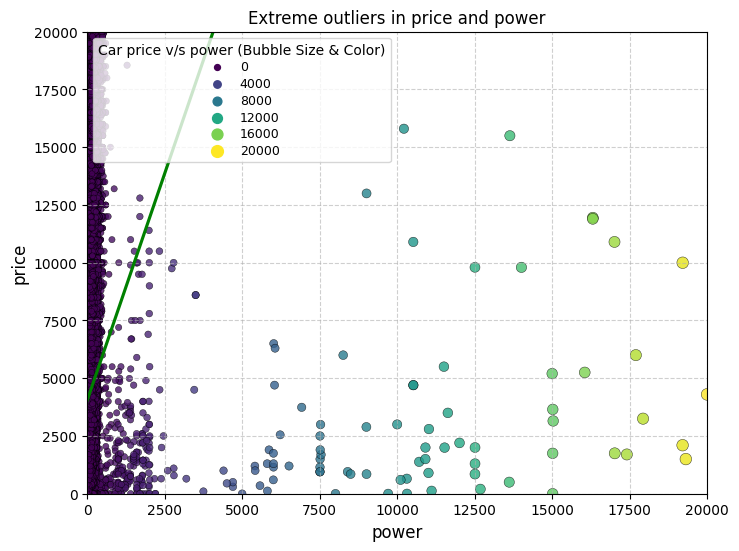

In [18]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='power', y='price',
                hue='power', size='power', palette='viridis', alpha=0.8, edgecolor='black')

sns.regplot(x=df['power'],
            y=df['price'], scatter=False, color='green', ci=None)

plt.xlabel('power', fontsize=12)
plt.ylabel('price', fontsize=12)
plt.title('Extreme outliers in price and power')
plt.legend(title='Car price v/s power (Bubble Size & Color)',
           loc='upper left', labelspacing=0.3, fontsize=9,  title_fontsize=10)
plt.ylim(0, 20000)
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

In [19]:
df = df[df['price'] >= 300]
df = df[(df['power']>= 50) & (df['power']< 2000)]

In [20]:
df.describe()

,price,registrationyear,power,mileage
count,284317.000000,284317.000000,284317.000000,284317.000000
mean,5025.368673,2003.074807,123.864598,128297.833053
std,4617.137251,6.275742,62.431344,36588.800952
min,300.000000,1937.000000,50.000000,5000.000000
25%,1499.000000,1999.000000,82.000000,125000.000000
50%,3400.000000,2003.000000,115.000000,150000.000000
75%,7200.000000,2007.000000,150.000000,150000.000000
max,20000.000000,2016.000000,1999.000000,150000.000000


##### There were some abnormal values in power column like 20000. Usually vehicle power ranges from 50 - 2000 so I adjusted the column accordingly because as it looks like data entry mistake. The price had some outliers like zeros. It will help with accurate model training.

## Model training 

In [21]:
## defining variable x and y
x = df.drop('price', axis=1)
y= df['price']

In [22]:
## splitting into training, validation and testing set
x_train, x_valid, y_train, y_valid = train_test_split(x, y, test_size =0.3, random_state=42)

x_test, x_valid, y_test, y_valid = train_test_split(x_valid, y_valid, test_size =0.5, random_state=42)

In [23]:
print(x_train.shape)
print(x_valid.shape)
print(y_train.shape)
print(y_valid.shape)
print(x_test.shape)
print(y_test.shape)



(199021, 9)
(42648, 9)
(199021,)
(42648,)
(42648, 9)
(42648,)


In [24]:
##  making sure there is no missing values
x_train.isna().sum()

vehicletype         0
registrationyear    0
gearbox             0
power               0
model               0
mileage             0
fueltype            0
brand               0
notrepaired         0
dtype: int64

In [25]:
x_train.dtypes

vehicletype         object
registrationyear     int64
gearbox             object
power                int64
model               object
mileage              int64
fueltype            object
brand               object
notrepaired         object
dtype: object

In [26]:
# Define the columns
numeric = ['registrationyear','power', 'mileage']
categorical = ['vehicletype','model','gearbox','fueltype','notrepaired', 'brand']

# Create a column transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical)])

# Fit and transform the data
x_train_transformed = preprocessor.fit_transform(x_train)
x_valid_transformed = preprocessor.transform(x_valid)
x_test_transformed = preprocessor.transform(x_test)


In [27]:
x_train[numeric].shape

(199021, 3)

In [28]:
%%time

print('Decision Tree')
model = DecisionTreeRegressor(random_state= 1234, max_depth=10)
model.fit(x_train_transformed,y_train)
y_pred = model.predict(x_valid_transformed)
rmse = mean_squared_error(y_pred, y_valid) **0.5
print("RMSE of the model with depth 10 on validation set:", rmse)


Decision Tree
RMSE of the model with depth 10 on validation set: 1966.8714914203251
CPU times: user 2.15 s, sys: 0 ns, total: 2.15 s
Wall time: 2.17 s


In [29]:
%%time
print('Decision Tree')
model = DecisionTreeRegressor(random_state= 1234, max_depth=20)
start_time =time.perf_counter()
model.fit(x_train_transformed,y_train)
end_time =time.perf_counter()
train_time = end_time - start_time
pred_start_time =time.perf_counter()
y_pred = model.predict(x_valid_transformed)
pred_end_time =time.perf_counter()
pred_time = pred_end_time - pred_start_time
rmse = mean_squared_error(y_pred, y_valid) **0.5

print("RMSE of the model with depth 20 on validation set:", rmse)
print('Model training time:', train_time)
print('Model prediction time:', pred_time)

Decision Tree
RMSE of the model with depth 20 on validation set: 1834.3702000373657
Model training time: 12.125184884294868
Model prediction time: 0.007807495072484016
CPU times: user 12.1 s, sys: 0 ns, total: 12.1 s
Wall time: 12.1 s


##### DecisionTreeRegression model validation set of depth= 20,  RMSE is 1834.37.This is the best model among the 2 models which was trained for decision tree.

In [30]:

%%time
print('RandomForest')

model = RandomForestRegressor(random_state=12345, n_estimators=100, max_depth=10) # initialize model constructor with parameters random_state=12345 and n_estimators=est
model.fit(x_train_transformed, y_train) # train model on training set
predictions_valid = model.predict(x_valid_transformed) # get model predictions on validation set
rmse = mean_squared_error(y_valid, predictions_valid) **0.5 
     

print("RMSE of the model with depth of 10 on the validation set:", rmse)

RandomForest
RMSE of the model with depth of 10 on the validation set: 1882.0295268031136
CPU times: user 2min 39s, sys: 70.9 ms, total: 2min 40s
Wall time: 2min 40s


In [31]:

%%time
print('RandomForest')

model = RandomForestRegressor(random_state=12345, n_estimators=100, max_depth=20) # initialize model constructor with parameters random_state=12345 and n_estimators=est
start_time =time.perf_counter()
model.fit(x_train_transformed, y_train) # train model on training set
end_time =time.perf_counter()
train_time = end_time- start_time
pred_start_time=time.perf_counter()
predictions_valid = model.predict(x_valid_transformed) # get model predictions on validation set
pred_end_time=time.perf_counter()
pred_time = pred_end_time - pred_start_time 
rmse = mean_squared_error(y_valid, predictions_valid) **0.5 
     

print("RMSE of the model with depth of 20 on the validation set:", rmse)
print('Model training time:', train_time)
print('Model prediction time:', pred_time)

RandomForest
RMSE of the model with depth of 20 on the validation set: 1580.140350645963
Model training time: 923.7400610540062
Model prediction time: 0.6654306370764971
CPU times: user 15min 23s, sys: 504 ms, total: 15min 23s
Wall time: 15min 24s


#### RandomForestRegressor model validation set with depth=20, RMSE is 1580.14. This is the best model among the two models trained by Random forest. But it is not very profitable in companies as it take too much time to run the code.

In [32]:
%%time

model = LinearRegression()

start_time =time.perf_counter()
model.fit(x_train_transformed, y_train)
end_time =time.perf_counter()
train_time = end_time- start_time

pred_start_time=time.perf_counter()
predictions_valid = model.predict(x_valid_transformed)
pred_end_time=time.perf_counter()
pred_time = pred_end_time - pred_start_time 

rmse = mean_squared_error(predictions_valid, y_valid) ** 0.5

print('RMSE of linear regression', rmse)
print('Model training time:', train_time)
print('Model prediction time:', pred_time)

RMSE of linear regression 2663.247828009431
Model training time: 8.014497863128781
Model prediction time: 0.0006835721433162689
CPU times: user 2.93 s, sys: 5.16 s, total: 8.08 s
Wall time: 8.03 s


#### LinearRegression model training results a RMSE is 2663.24 which is pretty high than the other models like DecisionTreeRegressor or RandomForestRegressor.

In [33]:
%%time

model_lgb= lgb.LGBMRegressor()

start_time =time.perf_counter()
model_lgb.fit(x_train_transformed, y_train)
end_time =time.perf_counter()
train_time = end_time - start_time

pred_start_time =time.perf_counter()
y_pred = model_lgb.predict(x_valid_transformed)
pred_end_time =time.perf_counter()
pred_time = pred_end_time- pred_start_time
rmse = mean_squared_error(y_pred, y_valid) ** 0.5

print('RMSE of Light GBM', rmse)
print('Model training time:', train_time)
print('Model prediction time:', pred_time)


RMSE of Light GBM 1658.698246207492
Model training time: 2.3005942795425653
Model prediction time: 0.2080971971154213
CPU times: user 2.5 s, sys: 44.2 ms, total: 2.55 s
Wall time: 2.51 s


### 

##### LightGBMRegressor model validation set RMSE is 1658.69.
##### The light gradient boosting model(LightGBM Regressor) performed better than Linear Regression model as LightGBM Regressor's RMSE was lower than the Linear Regression.

In [34]:
%%time
model = CatBoostRegressor(verbose=0)
param_grid= { 
    'depth':[5],
    'learning_rate':[0.1],
    'iterations':[200],
    'random_seed':[42]
}
grid_search = GridSearchCV(estimator=model,
param_grid=param_grid,
scoring='neg_root_mean_squared_error', cv=3)

start_time =time.perf_counter()
grid_search.fit(x_train_transformed, y_train)
end_time =time.perf_counter()
train_time = end_time - start_time

best_params = grid_search.best_params_
best_score = grid_search.best_score_

print('Best Parameters:', best_params)
print('Best RMSE:',-best_score)
print('Model training time:', train_time)


Best Parameters: {'depth': 5, 'iterations': 200, 'learning_rate': 0.1, 'random_seed': 42}
Best RMSE: 1737.2515181830568
Model training time: 12.400490883737803
CPU times: user 11.9 s, sys: 52 ms, total: 12 s
Wall time: 12.4 s


In [35]:
%%time

model = CatBoostRegressor(verbose=0)
param_grid= { 
    'depth':[10],
    'learning_rate':[0.1],
    'iterations':[200],
    'random_seed':[42]
}
grid_search = GridSearchCV(estimator=model,
param_grid=param_grid,
scoring='neg_root_mean_squared_error', cv=3)

start_time =time.perf_counter()
grid_search.fit(x_train_transformed, y_train)
end_time =time.perf_counter()
train_time = end_time - start_time

best_params = grid_search.best_params_
best_score = grid_search.best_score_

print('Best Parameters:', best_params)
print('Best RMSE:',-best_score)
print('Model training time:', train_time)

Best Parameters: {'depth': 10, 'iterations': 200, 'learning_rate': 0.1, 'random_seed': 42}
Best RMSE: 1612.9544349938533
Model training time: 30.481772530823946
CPU times: user 30.1 s, sys: 35.9 ms, total: 30.1 s
Wall time: 30.5 s


##### CatBoostRegressor model validation set RMSE is 1612.95. This model is best for handling categorical features effectively, making it suitable for datasets with many categorical variables.
##### The advanced gradient boosting model(CatBoostRegressor) performed better than Linear Regression model as CatBoostRegressor's RMSE was lower than the Linear Regression.

In [36]:
%%time

model_xgb = XGBRegressor(n_estimators=100, learning_rate=0.1)
start_time =time.perf_counter()
model_xgb.fit(x_train_transformed, y_train)
end_time =time.perf_counter()
train_time= end_time- start_time
pred_start_time = time.perf_counter()
predictions = model_xgb.predict(x_valid_transformed)
pred_end_time = time.perf_counter()
pred_time = pred_end_time - pred_start_time
rmse = mean_squared_error(predictions, y_valid) **0.5
print(f'RMSE of XGBRegressor:', rmse)
print('Model training time:', train_time)
print('Model prediction time:', pred_time)


RMSE of XGBRegressor: 1676.723341797302
Model training time: 17.509902166202664
Model prediction time: 0.18604704178869724
CPU times: user 17.7 s, sys: 25.4 ms, total: 17.7 s
Wall time: 17.7 s


In [37]:
%%time

start_time =time.perf_counter()
predictions = model_xgb.predict(x_test_transformed)
end_time = time.perf_counter()
xgb_prediction_time = end_time - start_time
xgb_rmse = mean_squared_error(predictions, y_test) **0.5
print(f'XGB RMSE:{xgb_rmse}')
print(f'XGB Prediction Time:{xgb_prediction_time}seconds')

XGB RMSE:1705.0581242883477
XGB Prediction Time:0.19790203124284744seconds
CPU times: user 190 ms, sys: 0 ns, total: 190 ms
Wall time: 199 ms


##### XGBoostRegressor model validation set RMSE is 1676.72.
##### XGBoost Regressor model was better in prediction time than the LightGBM. 
##### The training time is smaller than the LightGBM because it is considered a high performance implementation of gradient boosting known for its speed and scalibility due to parallel processing.

### 

In [38]:
%%time

start_time = time.perf_counter()
y_pred_test = model_lgb.predict(x_test_transformed)
end_time = time.perf_counter()
lgb_prediction_time = end_time - start_time
lgb_rmse = mean_squared_error(y_test, y_pred_test) ** 0.5
print(f'LightGBM RMSE:{lgb_rmse}')
print(f'LightGBM Prediction Time:{lgb_prediction_time}seconds')

LightGBM RMSE:1681.7399952002802
LightGBM Prediction Time:0.21245737187564373seconds
CPU times: user 247 ms, sys: 0 ns, total: 247 ms
Wall time: 213 ms


#### RMSE is 1681.73 when best model LightGBMRegressor ran on testing data set. So our model performed worse on the test data which proves that our model is overfitted.
#### The prediction time is lower compared to other models as well. 

In [39]:
%%time

from sklearn.dummy import DummyRegressor
dummy = DummyRegressor()
dummy.fit(x_train_transformed, y_train)
predictions = dummy.predict(x_valid_transformed)
rmse = mean_squared_error(predictions, y_valid) **0.5
print(f'RMSE of dummyRegressor:' , rmse)

RMSE of dummyRegressor: 4616.572921351008
CPU times: user 2.81 ms, sys: 16 µs, total: 2.82 ms
Wall time: 1.58 ms


##### It looks like our best model LightGBMRegressor is performing better than the dummy model.

## Conclusion

### We conclude that the LightGBMRegressor is the optimal model for Rusty Bargain used car sales services, accurately forecasting market values of used car prices. This assists prospective buyers in determining if a particular car is within their budget, leading to quicker sales conversions and benefiting both customers and employees.
#### The project started with data preprocessing dropped columns such as 'NumberOfPictures', 'PostalCode', 'LastSeen', 'DateCreated' and 'RegistrationMonth' were deemed not useful for our predictions as they have no impact on the price prediction of a car. I kept the data in RegistrationYear only which matches with the DateCrawled. There were some abnormal values in power column like 20000. Usually vehicle power ranges from 50 - 2000 so I adjusted the column accordingly because as it looks like data entry mistake. The price had some outliers like zeros. It will help with proper model training.
### We tried couple different models like DecisionTreeRegressor, RandomForestRegressor, LinearRegression and also some  gradient boosting model like LightGBMRegressor, CatBoostRegressor. 
### DecisionTreeRegressor model training resulted in an RMSE of 1834.37. RandomForestRegressor model training also resulted in an RMSE of 1580.14, but with a significantly longer training time. It has the bet training time among all the models But it is not very profitable in companies as it take too much time to run the code.The training time for decision tree was much faster and gave same result like random forest. The reason for faster training time is because one is using single tree and other one is using collection of trees.
### LightGBMRegressor model training achieved an RMSE of 1658.69 with a remarkably fast training time of 1.2 ms. 
### LightGBMRegressor's performance on the testing data was also impressive, with an RMSE of 1681.07 and a prediction time of 0.22 s. This confirms it as the best model for our prediction needs, outperforming the Linear Regression model. These are the benefits of lower RMSE and faster prediction times. It is also doing better than dummy model.
 #### Accurate Pricing: With a lower RMSE, the LightGBMRegressor provides more accurate price predictions. This helps customers to make informed decisions, ensuring that they get fair deals without overpaying or underestimating car values.
#### Quicker Sales:** Faster and more accurate price assessments lead to less hassle during negotiations, resulting in quicker sales conversions. This increases customer satisfaction as they can purchase cars more efficiently.
#### Operational Efficiency:The reduced training and prediction times of the LightGBMRegressor mean that the model can be updated and deployed rapidly. This enhances the business's ability to adapt to market changes and keeps the price predictions up-to-date with minimal downtime.
#### Win-Win Situation:Accurate and efficient pricing benefits both customers and employees. Customers enjoy a smooth buying experience with reliable pricing information, while employees can handle transactions more efficiently and focus on providing excellent customer 

### CatBoostRegressor model training yielded an RMSE of 1612.95. This advanced gradient boosting model also outperformed the Linear Regression model in terms of RMSE. This model give lower RMSE but it consumes too much time to training a model which is not feasible in companies.
### XGBoostRegressor model training results a RMSE of 1681.78 with less training time than CatBoost model.  The training time is smaller than the LightGBM because it is considered a high performance implementation of gradient boosting known for its speed and scalibility due to parallel processing.
### LinearRegression model training resulted in an RMSE of 2663.24, which is higher than the other models like DecisionTreeRegressor and RandomForestRegressor.
